CONFIGURATION & IMPORTS

In [1]:
# Manipulation de données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

# NLP - Natural Language Processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re
import string

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    confusion_matrix, 
    classification_report
)

# Utilitaires
import warnings
from datetime import datetime
import time
import pickle

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

# Style des graphiques
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

#nltk.download('stopwords')
#nltk.download('punkt')
#nltk.download('wordnet')
#nltk.download('vader_lexicon')

print("Bibliothèques importées ")


Bibliothèques importées 


CHARGEMENT DES DONNÉES

In [2]:
# Charge le dataset
df = pd.read_csv('data/reviews.csv')


print(" DONNÉES CHARGÉES AVEC SUCCÈS")


print(f"\n INFORMATIONS GÉNÉRALES")
print(f"   Nombre total d'avis : {len(df):,}")
print(f"   Nombre de colonnes : {df.shape[1]}")
print(f"   Colonnes : {list(df.columns)}")
print(f"   Mémoire utilisée : {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")


print(" APERÇU DES DONNÉES")
display(df.head(10))

print(" INFORMATIONS DÉTAILLÉES")
df.info()

print(" STATISTIQUES DESCRIPTIVES")
display(df.describe())

 DONNÉES CHARGÉES AVEC SUCCÈS

 INFORMATIONS GÉNÉRALES
   Nombre total d'avis : 568,454
   Nombre de colonnes : 10
   Colonnes : ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']
   Mémoire utilisée : 313.06 MB
 APERÇU DES DONNÉES


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned dog food products and have found them all to be of ...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all","This is a confection that has been around a few centuries. It is a light, pillowy citrus gelati..."
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient in Robitussin I believe I have found it. I got thi...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wide assortment of yummy taffy. Delivery was very qu...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this five pound bag. The taffy was all very enjoyable wi...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was very soft and chewy. Each candy was individually...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and chewy. The flavors are amazing. I would definitely...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my cats can eat the grass. They love it. I rotate it...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for their digestion. Also good for small puppies. My dog e...


 INFORMATIONS DÉTAILLÉES
<class 'pandas.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype
---  ------                  --------------   -----
 0   Id                      568454 non-null  int64
 1   ProductId               568454 non-null  str  
 2   UserId                  568454 non-null  str  
 3   ProfileName             568428 non-null  str  
 4   HelpfulnessNumerator    568454 non-null  int64
 5   HelpfulnessDenominator  568454 non-null  int64
 6   Score                   568454 non-null  int64
 7   Time                    568454 non-null  int64
 8   Summary                 568427 non-null  str  
 9   Text                    568454 non-null  str  
dtypes: int64(5), str(5)
memory usage: 313.1 MB
 STATISTIQUES DESCRIPTIVES


,Id,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time
count,568454.000000,568454.000000,568454.00000,568454.000000,5.684540e+05
mean,284227.500000,1.743817,2.22881,4.183199,1.296257e+09
std,164098.679298,7.636513,8.28974,1.310436,4.804331e+07
min,1.000000,0.000000,0.00000,1.000000,9.393408e+08
25%,142114.250000,0.000000,0.00000,4.000000,1.271290e+09
50%,284227.500000,0.000000,1.00000,5.000000,1.311120e+09
75%,426340.750000,2.000000,2.00000,5.000000,1.332720e+09
max,568454.000000,866.000000,923.00000,5.000000,1.351210e+09


EXPLORATION DES DONNÉES

In [3]:
print(" EXPLORATION DES DONNÉES")


# Distribution des scores
print("\n DISTRIBUTION DES SCORES")
score_distribution = df['Score'].value_counts().sort_index()
print(score_distribution)

# Création des catégories de sentiment
def categorize_sentiment(score):
    """Convertit le score en catégorie de sentiment"""
    if score >= 4:
        return 'Positif'
    elif score <= 2:
        return 'Négatif'
    else:
        return 'Neutre'

df['Sentiment'] = df['Score'].apply(categorize_sentiment)

print("\n DISTRIBUTION DES SENTIMENTS")
sentiment_counts = df['Sentiment'].value_counts()
print(sentiment_counts)
print(f"\nPourcentages :")
print(df['Sentiment'].value_counts(normalize=True) * 100)

# Vérification des valeurs manquantes
print("\n VALEURS MANQUANTES")
missing_values = df.isnull().sum()
print(missing_values)
print(f"\nTotal : {missing_values.sum()}")

# Statistiques sur la longueur des textes
df['Text_Length'] = df['Text'].apply(len)
df['Word_Count'] = df['Text'].apply(lambda x: len(str(x).split()))

print("\n STATISTIQUES SUR LES TEXTES")
print(f"    Longueur moyenne : {df['Text_Length'].mean():.0f} caractères")
print(f"    Longueur médiane : {df['Text_Length'].median():.0f} caractères")
print(f"    Nombre de mots moyen : {df['Word_Count'].mean():.0f} mots")
print(f"    Texte le plus court : {df['Text_Length'].min()} caractères")
print(f"    Texte le plus long : {df['Text_Length'].max()} caractères")

# Exemples d'avis par sentiment
print(" EXEMPLES D'AVIS PAR SENTIMENT")

for sentiment in ['Positif', 'Neutre', 'Négatif']:
    print(f"\n{sentiment.upper()} :")
    samples = df[df['Sentiment'] == sentiment]['Text'].sample(3, random_state=42)
    for i, text in enumerate(samples, 1):
        print(f"   {i}. {text[:100]}...")

 EXPLORATION DES DONNÉES

 DISTRIBUTION DES SCORES
Score
1     52268
2     29769
3     42640
4     80655
5    363122
Name: count, dtype: int64

 DISTRIBUTION DES SENTIMENTS
Sentiment
Positif    443777
Négatif     82037
Neutre      42640
Name: count, dtype: int64

Pourcentages :
Sentiment
Positif    78.067355
Négatif    14.431599
Neutre      7.501047
Name: proportion, dtype: float64

 VALEURS MANQUANTES
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
Sentiment                  0
dtype: int64

Total : 53

 STATISTIQUES SUR LES TEXTES
    Longueur moyenne : 436 caractères
    Longueur médiane : 302 caractères
    Nombre de mots moyen : 80 mots
    Texte le plus court : 12 caractères
    Texte le plus long : 21409 caractères
 EXEMPLES D'AVIS PAR SENTIM

VISUALISATIONS

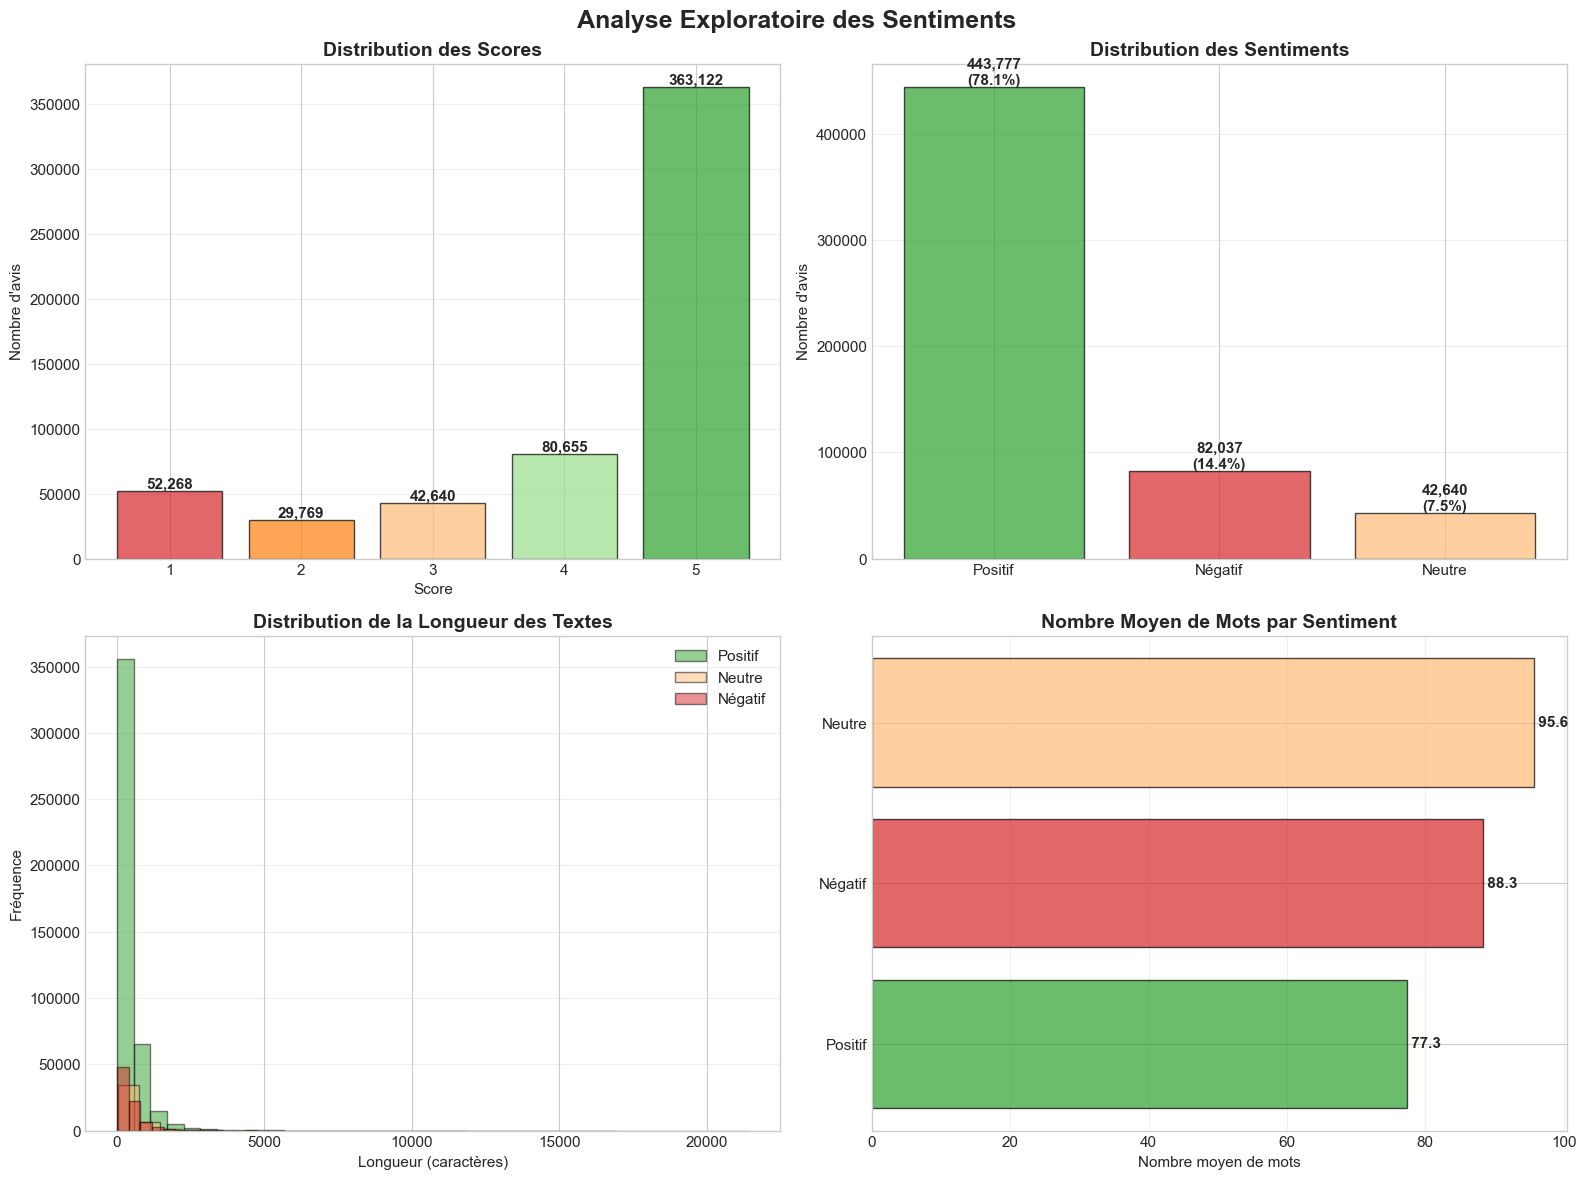

 Visualisations sauvegardées : images/exploratory_analysis.png


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle(' Analyse Exploratoire des Sentiments', fontsize=18, fontweight='bold')

# GRAPHIQUE 1 : Distribution des scores

colors_scores = ['#d62728', '#ff7f0e', '#ffbb78', '#98df8a', '#2ca02c']
bars1 = axes[0, 0].bar(score_distribution.index, score_distribution.values,
                       color=colors_scores, edgecolor='black', alpha=0.7)

axes[0, 0].set_title('Distribution des Scores', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Score', fontsize=11)
axes[0, 0].set_ylabel('Nombre d\'avis', fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)

for bar in bars1:
    height = bar.get_height()
    axes[0, 0].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}',
                    ha='center', va='bottom', fontweight='bold')


# GRAPHIQUE 2 : Distribution des sentiments

sentiment_colors = {'Positif': '#2ca02c', 'Neutre': '#ffbb78', 'Négatif': '#d62728'}
colors = [sentiment_colors[s] for s in sentiment_counts.index]

bars2 = axes[0, 1].bar(sentiment_counts.index, sentiment_counts.values,
                       color=colors, edgecolor='black', alpha=0.7)

axes[0, 1].set_title('Distribution des Sentiments', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Nombre d\'avis', fontsize=11)
axes[0, 1].grid(axis='y', alpha=0.3)

for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height):,}\n({height/len(df)*100:.1f}%)',
                    ha='center', va='bottom', fontweight='bold')


# GRAPHIQUE 3 : Distribution de la longueur des textes

for sentiment in ['Positif', 'Neutre', 'Négatif']:
    data = df[df['Sentiment'] == sentiment]['Text_Length']
    axes[1, 0].hist(data, bins=30, alpha=0.5, label=sentiment, 
                    color=sentiment_colors[sentiment], edgecolor='black')

axes[1, 0].set_title('Distribution de la Longueur des Textes', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Longueur (caractères)', fontsize=11)
axes[1, 0].set_ylabel('Fréquence', fontsize=11)
axes[1, 0].legend()
axes[1, 0].grid(axis='y', alpha=0.3)

# GRAPHIQUE 4 : Nombre de mots par sentiment

word_count_by_sentiment = df.groupby('Sentiment')['Word_Count'].mean().sort_values()

bars4 = axes[1, 1].barh(word_count_by_sentiment.index, word_count_by_sentiment.values,
                        color=[sentiment_colors[s] for s in word_count_by_sentiment.index],
                        edgecolor='black', alpha=0.7)

axes[1, 1].set_title('Nombre Moyen de Mots par Sentiment', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Nombre moyen de mots', fontsize=11)
axes[1, 1].grid(axis='x', alpha=0.3)

for i, bar in enumerate(bars4):
    width = bar.get_width()
    axes[1, 1].text(width, bar.get_y() + bar.get_height()/2.,
                    f' {width:.1f}',
                    ha='left', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('images/exploratory_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(" Visualisations sauvegardées : images/exploratory_analysis.png")

PREPROCESSING & NETTOYAGE DU TEXTE

In [7]:
import nltk
import ssl
import os
import sys

# Fix SSL issues if any
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

# Set a local directory for NLTK data
nltk_data_dir = os.path.join(os.path.expanduser('~'), 'nltk_data')
if nltk_data_dir not in nltk.data.path:
    nltk.data.path.append(nltk_data_dir)

# Force download of required resources
print("Téléchargement des ressources NLTK...")
try:
    nltk.download('punkt', download_dir=nltk_data_dir, quiet=False)
    nltk.download('stopwords', download_dir=nltk_data_dir, quiet=False)
    nltk.download('punkt_tab', download_dir=nltk_data_dir, quiet=False)
    nltk.download('wordnet', download_dir=nltk_data_dir, quiet=False)
    nltk.download('omw-1.4', download_dir=nltk_data_dir, quiet=False)
    print("Tous les ressources ont été téléchargées avec succès!")
except Exception as e:
    print(f"Erreur lors du téléchargement: {e}")
    
# Verify downloads
print("\nVérification des ressources:")
print(f"punkt disponible: {nltk.data.find('tokenizers/punkt') if nltk.data.find('tokenizers/punkt') else 'Non'}")
print(f"punkt_tab disponible: {nltk.data.find('tokenizers/punkt_tab') if hasattr(nltk.data, 'find') else 'Vérification manuelle'}")

Téléchargement des ressources NLTK...


[nltk_data] Downloading package punkt to C:\Users\USER\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\USER\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\USER\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\USER\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\USER\nltk_data...


Tous les ressources ont été téléchargées avec succès!

Vérification des ressources:
punkt disponible: C:\Users\USER\nltk_data\tokenizers\punkt
punkt_tab disponible: C:\Users\USER\nltk_data\tokenizers\punkt_tab


In [ ]:
print(" PREPROCESSING DU TEXTE")

# Initialise les outils NLTK
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    """
    Nettoie et prétraite le texte.
    Les etapes :
    1. Convertir en minuscules
    2. Supprimer les URLs
    3. Supprimer les mentions (@username)
    4. Supprimer les caractères spéciaux et chiffres
    5. Tokenize (découpe en mots)
    6. Supprimer les stop words
    7. Lemmatize (réduit au radical)
    """
    
    # Convertit en minuscules
    text = str(text).lower()
    
    # Supprime les URLs
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    
    # Supprime les mentions (@username)
    text = re.sub(r'@\w+', '', text)
    
    # Supprime les hashtags (garde le texte)
    text = re.sub(r'#', '', text)
    
    # Supprime la ponctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    
    # Supprime les chiffres
    text = re.sub(r'\d+', '', text)
    
    # Tokenize : split suffit après suppression de la ponctuation (word_tokenize / Punkt est très lent)
    tokens = text.split()
    
    # Supprime les stop words et lemmatize
    cleaned_tokens = []
    for token in tokens:
        if token not in stop_words and len(token) > 2:  # Garde seulement les mots > 2 lettres
            lemmatized = lemmatizer.lemmatize(token)
            cleaned_tokens.append(lemmatized)
    
    # Rejoint les tokens
    cleaned_text = ' '.join(cleaned_tokens)
    
    return cleaned_text

# Applique le preprocessing
print("\n Nettoyage des textes en cours...")
start_time = time.time()

df['Cleaned_Text'] = df['Text'].astype(str).map(clean_text)

processing_time = time.time() - start_time
print(f" Preprocessing terminé en {processing_time:.2f} secondes")

# Affiche des exemples avant/après
print(" EXEMPLES AVANT/APRÈS PREPROCESSING")

for i in range(3):
    print(f"\n--- Exemple {i+1} ---")
    print(f"AVANT : {df['Text'].iloc[i][:150]}...")
    print(f"APRÈS : {df['Cleaned_Text'].iloc[i][:150]}...")

# Supprime les lignes avec des textes vides après nettoyage
initial_len = len(df)
df = df[df['Cleaned_Text'].str.strip() != '']
final_len = len(df)

print(f"\n Lignes supprimées (textes vides) : {initial_len - final_len}")
print(f" Dataset final : {final_len:,} avis")

# Réinitialise l'index
df = df.reset_index(drop=True)

# Sauvegarde le dataset nettoyé
df.to_csv('data/reviews_cleaned.csv', index=False)
print("\n Dataset nettoyé sauvegardé : data/reviews_cleaned.csv")

 PREPROCESSING DU TEXTE

 Nettoyage des textes en cours...
 Preprocessing terminé en 89.43 secondes
 EXEMPLES AVANT/APRÈS PREPROCESSING

--- Exemple 1 ---
AVANT : I have bought several of the Vitality canned dog food products and have found them all to be of good quality. The product looks more like a stew than ...
APRÈS : bought several vitality canned dog food product found good quality product look like stew processed meat smell better labrador finicky appreciates pro...

--- Exemple 2 ---
AVANT : Product arrived labeled as Jumbo Salted Peanuts...the peanuts were actually small sized unsalted. Not sure if this was an error or if the vendor inten...
APRÈS : product arrived labeled jumbo salted peanutsthe peanut actually small sized unsalted sure error vendor intended represent product jumbo...

--- Exemple 3 ---
AVANT : This is a confection that has been around a few centuries.  It is a light, pillowy citrus gelatin with nuts - in this case Filberts. And it is cut int...
APRÈS : conf

SPLIT TRAIN/TEST

In [13]:
# 6. SPLIT TRAIN/TEST

print(" SPLIT DES DONNÉES")

# Features (X) et Target (y)
X = df['Cleaned_Text']
y = df['Sentiment']

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Garde la même proportion de chaque classe
)

print(f"\n RÉPARTITION DES DONNÉES")
print(f"    Training set : {len(X_train):,} avis ({len(X_train)/len(df)*100:.1f}%)")
print(f"    Test set : {len(X_test):,} avis ({len(X_test)/len(df)*100:.1f}%)")

print(f"\n DISTRIBUTION DES SENTIMENTS (Training)")
print(y_train.value_counts())
print(f"\n DISTRIBUTION DES SENTIMENTS (Test)")
print(y_test.value_counts())

print("\n Split effectué avec succès")

 SPLIT DES DONNÉES

 RÉPARTITION DES DONNÉES
    Training set : 454,756 avis (80.0%)
    Test set : 113,690 avis (20.0%)

 DISTRIBUTION DES SENTIMENTS (Training)
Sentiment
Positif    355015
Négatif     65629
Neutre      34112
Name: count, dtype: int64

 DISTRIBUTION DES SENTIMENTS (Test)
Sentiment
Positif    88754
Négatif    16408
Neutre      8528
Name: count, dtype: int64

 Split effectué avec succès


FEATURE ENGINEERING - TF-IDF

In [14]:
# 7. FEATURE ENGINEERING - TF-IDF


print(" FEATURE ENGINEERING - TF-IDF")

print("\n TF-IDF (Term Frequency - Inverse Document Frequency)")
print("   Transforme le texte en vecteurs numériques.")
print("   Les mots fréquents mais peu informatifs ont un score faible.")

# Configuration du vectorizer
tfidf_vectorizer = TfidfVectorizer(
    max_features=5000,      # Garde les 5000 mots les plus importants
    ngram_range=(1, 2),     # Unigrams et bigrams (mots seuls et paires)
    min_df=2,               # Mot doit apparaître dans au moins 2 documents
    max_df=0.8,             # Mot ne doit pas apparaître dans plus de 80% des docs
)

print("\n Vectorisation en cours...")
start_time = time.time()

# Fit sur le training set et transform
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

vectorization_time = time.time() - start_time
print(f" Vectorisation terminée en {vectorization_time:.2f} secondes")

print(f"\n SHAPE DES MATRICES")
print(f"   • X_train_tfidf : {X_train_tfidf.shape}")
print(f"   • X_test_tfidf : {X_test_tfidf.shape}")
print(f"   • Nombre de features (mots) : {len(tfidf_vectorizer.get_feature_names_out()):,}")

# Top 20 mots les plus importants
feature_names = tfidf_vectorizer.get_feature_names_out()
tfidf_scores = X_train_tfidf.sum(axis=0).A1  # Somme des scores TF-IDF
top_indices = tfidf_scores.argsort()[-20:][::-1]
top_words = [(feature_names[i], tfidf_scores[i]) for i in top_indices]

print(f"\n TOP 20 MOTS LES PLUS IMPORTANTS (TF-IDF)")
for i, (word, score) in enumerate(top_words, 1):
    print(f"   {i:2d}. {word:20s} : {score:.2f}")

# Sauvegarde le vectorizer
with open('models/tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

print("\n Vectorizer sauvegardé : models/tfidf_vectorizer.pkl")

 FEATURE ENGINEERING - TF-IDF

 TF-IDF (Term Frequency - Inverse Document Frequency)
   Transforme le texte en vecteurs numériques.
   Les mots fréquents mais peu informatifs ont un score faible.

 Vectorisation en cours...
 Vectorisation terminée en 77.91 secondes

 SHAPE DES MATRICES
   • X_train_tfidf : (454756, 5000)
   • X_test_tfidf : (113690, 5000)
   • Nombre de features (mots) : 5,000

 TOP 20 MOTS LES PLUS IMPORTANTS (TF-IDF)
    1. like                 : 12042.10
    2. coffee               : 11496.70
    3. taste                : 11040.96
    4. good                 : 10984.46
    5. great                : 10704.11
    6. love                 : 10554.01
    7. tea                  : 10377.22
    8. product              : 10362.30
    9. flavor               : 10035.49
   10. one                  : 9424.88
   11. food                 : 8037.92
   12. dog                  : 7684.82
   13. would                : 6995.37
   14. get                  : 6962.42
   15. really      

MODÈLE 1 : LOGISTIC REGRESSION

 MODÈLE 1 : LOGISTIC REGRESSION

 PRINCIPE :
   Classification linéaire simple mais efficace.
   Idéal pour des problèmes de classification de texte.

 Entraînement en cours...
 Entraînement terminé en 13.85 secondes

 Prédictions sur le test set...

 RÉSULTATS
   Accuracy  : 0.8692 (86.92%)
   Precision : 0.8498
   Recall    : 0.8692
   F1-Score  : 0.8529

 RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

      Neutre       0.52      0.19      0.28      8528
     Négatif       0.74      0.69      0.72     16408
     Positif       0.90      0.97      0.93     88754

    accuracy                           0.87    113690
   macro avg       0.72      0.62      0.64    113690
weighted avg       0.85      0.87      0.85    113690


 MATRICE DE CONFUSION


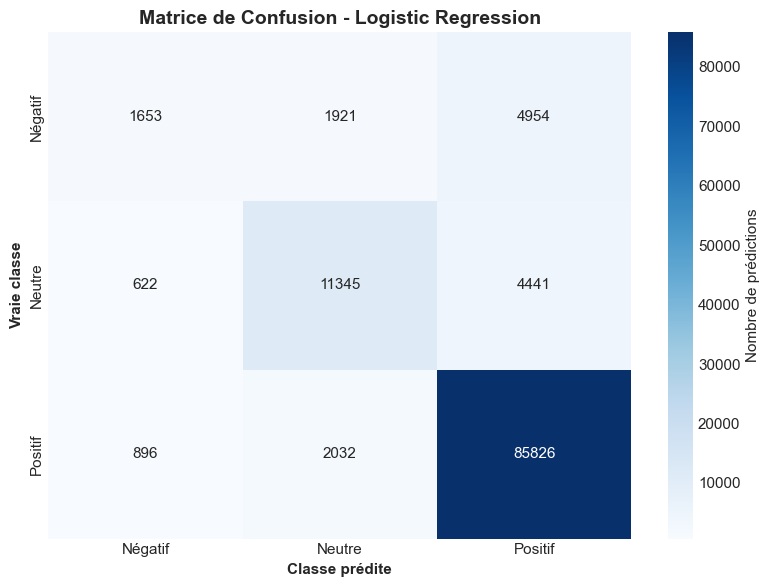


 INTERPRÉTATION :
   Le modèle a correctement classifié 86.9% des avis.


In [27]:
print(" MODÈLE 1 : LOGISTIC REGRESSION")

print("\n PRINCIPE :")
print("   Classification linéaire simple mais efficace.")
print("   Idéal pour des problèmes de classification de texte.")

# Entraînement
print("\n Entraînement en cours...")
start_time = time.time()

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42,
    C=1.0,  # Régularisation
    solver='lbfgs'
)

lr_model.fit(X_train_tfidf, y_train)

train_time_lr = time.time() - start_time
print(f" Entraînement terminé en {train_time_lr:.2f} secondes")

# Prédictions
print("\n Prédictions sur le test set...")
y_pred_lr = lr_model.predict(X_test_tfidf)

# Métriques
accuracy_lr = accuracy_score(y_test, y_pred_lr)
precision_lr = precision_score(y_test, y_pred_lr, average='weighted')
recall_lr = recall_score(y_test, y_pred_lr, average='weighted')
f1_lr = f1_score(y_test, y_pred_lr, average='weighted')

print(f"\n RÉSULTATS")
print(f"   Accuracy  : {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")
print(f"   Precision : {precision_lr:.4f}")
print(f"   Recall    : {recall_lr:.4f}")
print(f"   F1-Score  : {f1_lr:.4f}")

# Rapport de classification détaillé
print(f"\n RAPPORT DE CLASSIFICATION")
print(classification_report(y_test, y_pred_lr))

# Matrice de confusion
print(f"\n MATRICE DE CONFUSION")
cm_lr = confusion_matrix(y_test, y_pred_lr)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Négatif', 'Neutre', 'Positif'],
            yticklabels=['Négatif', 'Neutre', 'Positif'],
            cbar_kws={'label': 'Nombre de prédictions'})
ax.set_title('Matrice de Confusion - Logistic Regression', fontweight='bold', fontsize=14)
ax.set_ylabel('Vraie classe', fontweight='bold')
ax.set_xlabel('Classe prédite', fontweight='bold')
plt.tight_layout()
plt.savefig('images/confusion_matrix_lr.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n INTERPRÉTATION :")
print(f"   Le modèle a correctement classifié {accuracy_lr*100:.1f}% des avis.")

MODÈLE 2 : RANDOM FOREST

 MODÈLE 2 : RANDOM FOREST

 PRINCIPE :
   Ensemble d'arbres de décision.
   Généralement plus précis mais plus lent.

 Entraînement en cours...
 Entraînement terminé en 64.03 secondes

 Prédictions sur le test set...

 RÉSULTATS
    Accuracy  : 0.7894 (78.94%)
    Precision : 0.8319
    Recall    : 0.7894
    F1-Score  : 0.7046

 RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

      Neutre       1.00      0.00      0.01      8528
     Négatif       0.98      0.06      0.11     16408
     Positif       0.79      1.00      0.88     88754

    accuracy                           0.79    113690
   macro avg       0.92      0.35      0.33    113690
weighted avg       0.83      0.79      0.70    113690


 MATRICE DE CONFUSION


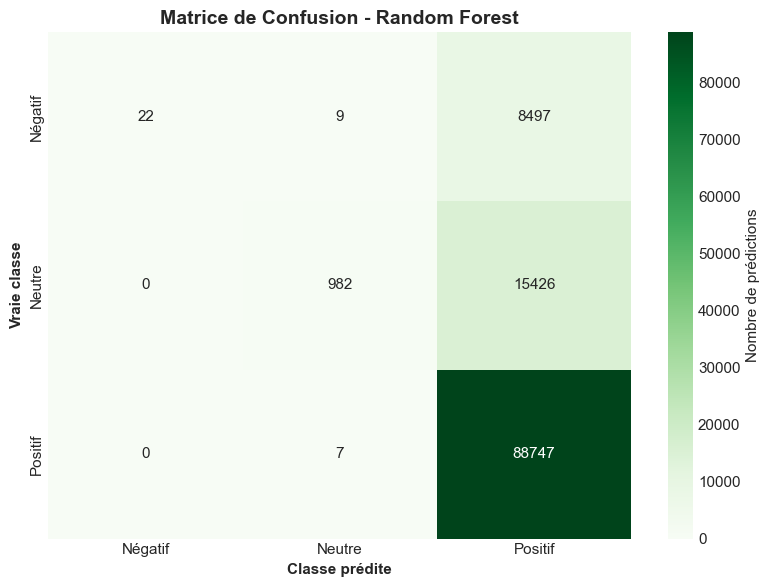


 COMPARAISON AVEC LOGISTIC REGRESSION :
   Logistic Regression est meilleur (+7.98%)


In [16]:
# 9. MODÈLE 2 : RANDOM FOREST


print(" MODÈLE 2 : RANDOM FOREST")


print("\n PRINCIPE :")
print("   Ensemble d'arbres de décision.")
print("   Généralement plus précis mais plus lent.")

# Entraînement
print("\n Entraînement en cours...")
start_time = time.time()

rf_model = RandomForestClassifier(
    n_estimators=100,      # Nombre d'arbres
    max_depth=20,          # Profondeur maximale
    random_state=42,
    n_jobs=-1,             # Utilise tous les CPU
    verbose=0
)

rf_model.fit(X_train_tfidf, y_train)

train_time_rf = time.time() - start_time
print(f" Entraînement terminé en {train_time_rf:.2f} secondes")

# Prédictions
print("\n Prédictions sur le test set...")
y_pred_rf = rf_model.predict(X_test_tfidf)

# Métriques
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf, average='weighted')
recall_rf = recall_score(y_test, y_pred_rf, average='weighted')
f1_rf = f1_score(y_test, y_pred_rf, average='weighted')

print(f"\n RÉSULTATS")
print(f"    Accuracy  : {accuracy_rf:.4f} ({accuracy_rf*100:.2f}%)")
print(f"    Precision : {precision_rf:.4f}")
print(f"    Recall    : {recall_rf:.4f}")
print(f"    F1-Score  : {f1_rf:.4f}")

# Rapport de classification
print(f"\n RAPPORT DE CLASSIFICATION")
print(classification_report(y_test, y_pred_rf))

# Matrice de confusion
print(f"\n MATRICE DE CONFUSION")
cm_rf = confusion_matrix(y_test, y_pred_rf)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens', 
            xticklabels=['Négatif', 'Neutre', 'Positif'],
            yticklabels=['Négatif', 'Neutre', 'Positif'],
            cbar_kws={'label': 'Nombre de prédictions'})
ax.set_title('Matrice de Confusion - Random Forest', fontweight='bold', fontsize=14)
ax.set_ylabel('Vraie classe', fontweight='bold')
ax.set_xlabel('Classe prédite', fontweight='bold')
plt.tight_layout()
plt.savefig('images/confusion_matrix_rf.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n COMPARAISON AVEC LOGISTIC REGRESSION :")
if accuracy_rf > accuracy_lr:
    print(f"   Random Forest est meilleur (+{(accuracy_rf - accuracy_lr)*100:.2f}%)")
else:
    print(f"   Logistic Regression est meilleur (+{(accuracy_lr - accuracy_rf)*100:.2f}%)")

MODÈLE 3 : NAIVE BAYES

 MODÈLE 3 : MULTINOMIAL NAIVE BAYES

 PRINCIPE :
   Basé sur le théorème de Bayes.
   Très rapide, souvent utilisé pour la classification de texte.

 Entraînement en cours...
 Entraînement terminé en 1.93 secondes

 Prédictions sur le test set...

 RÉSULTATS
   • Accuracy  : 0.8251 (82.51%)
   • Precision : 0.8070
   • Recall    : 0.8251
   • F1-Score  : 0.7748

 RAPPORT DE CLASSIFICATION
              precision    recall  f1-score   support

      Neutre       0.57      0.01      0.02      8528
     Négatif       0.83      0.34      0.48     16408
     Positif       0.83      0.99      0.90     88754

    accuracy                           0.83    113690
   macro avg       0.74      0.45      0.47    113690
weighted avg       0.81      0.83      0.77    113690


 MATRICE DE CONFUSION


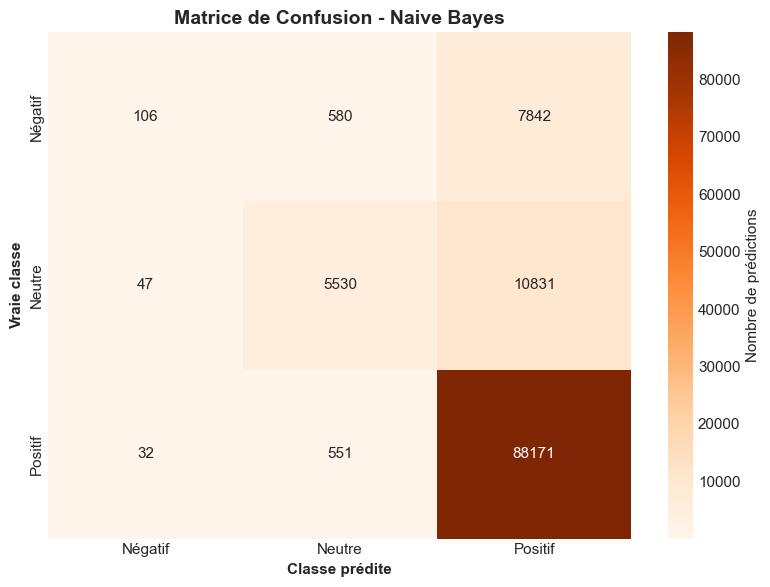


 VITESSE D'ENTRAÎNEMENT :
   Naive Bayes est 33.1x plus rapide que Random Forest


In [17]:
# 10. MODÈLE 3 : NAIVE BAYES

print(" MODÈLE 3 : MULTINOMIAL NAIVE BAYES")


print("\n PRINCIPE :")
print("   Basé sur le théorème de Bayes.")
print("   Très rapide, souvent utilisé pour la classification de texte.")

# Entraînement
print("\n Entraînement en cours...")
start_time = time.time()

nb_model = MultinomialNB(alpha=1.0)  # Smoothing parameter
nb_model.fit(X_train_tfidf, y_train)

train_time_nb = time.time() - start_time
print(f" Entraînement terminé en {train_time_nb:.2f} secondes")

# Prédictions
print("\n Prédictions sur le test set...")
y_pred_nb = nb_model.predict(X_test_tfidf)

# Métriques
accuracy_nb = accuracy_score(y_test, y_pred_nb)
precision_nb = precision_score(y_test, y_pred_nb, average='weighted')
recall_nb = recall_score(y_test, y_pred_nb, average='weighted')
f1_nb = f1_score(y_test, y_pred_nb, average='weighted')

print(f"\n RÉSULTATS")
print(f"   • Accuracy  : {accuracy_nb:.4f} ({accuracy_nb*100:.2f}%)")
print(f"   • Precision : {precision_nb:.4f}")
print(f"   • Recall    : {recall_nb:.4f}")
print(f"   • F1-Score  : {f1_nb:.4f}")

# Rapport de classification
print(f"\n RAPPORT DE CLASSIFICATION")
print(classification_report(y_test, y_pred_nb))

# Matrice de confusion
print(f"\n MATRICE DE CONFUSION")
cm_nb = confusion_matrix(y_test, y_pred_nb)

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=['Négatif', 'Neutre', 'Positif'],
            yticklabels=['Négatif', 'Neutre', 'Positif'],
            cbar_kws={'label': 'Nombre de prédictions'})
ax.set_title('Matrice de Confusion - Naive Bayes', fontweight='bold', fontsize=14)
ax.set_ylabel('Vraie classe', fontweight='bold')
ax.set_xlabel('Classe prédite', fontweight='bold')
plt.tight_layout()
plt.savefig('images/confusion_matrix_nb.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\n VITESSE D'ENTRAÎNEMENT :")
print(f"   Naive Bayes est {train_time_rf/train_time_nb:.1f}x plus rapide que Random Forest")

COMPARAISON DES PERFORMANCES

 COMPARAISON FINALE DES 3 MODÈLES


,Rang,Modèle,Accuracy,Precision,Recall,F1-Score,Temps (s)
0,1,Logistic Regression,0.869241,0.849774,0.869241,0.852856,18.670968
2,2,Naive Bayes,0.825112,0.807027,0.825112,0.774830,1.932576
1,3,Random Forest,0.789436,0.831929,0.789436,0.704591,64.028911


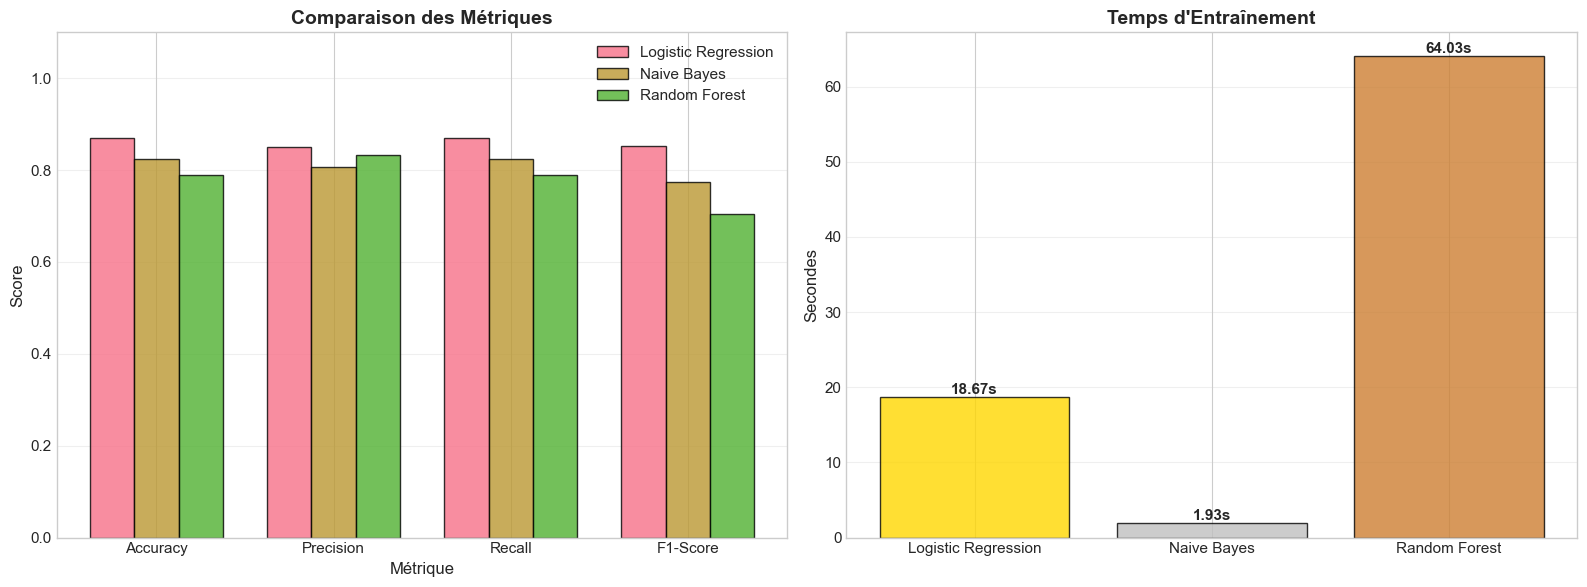


 Graphique sauvegardé : images/model_comparison.png

 MEILLEUR MODÈLE : Logistic Regression
    Accuracy : 0.8692 (86.92%)
    F1-Score : 0.8529

 Meilleur modèle sauvegardé : models/best_model.pkl
 Résultats sauvegardés : model_comparison.csv


In [18]:
# 11. COMPARAISON DES PERFORMANCES

print(" COMPARAISON FINALE DES 3 MODÈLES")

# Crée un DataFrame avec tous les résultats
results_df = pd.DataFrame({
    'Modèle': ['Logistic Regression', 'Random Forest', 'Naive Bayes'],
    'Accuracy': [accuracy_lr, accuracy_rf, accuracy_nb],
    'Precision': [precision_lr, precision_rf, precision_nb],
    'Recall': [recall_lr, recall_rf, recall_nb],
    'F1-Score': [f1_lr, f1_rf, f1_nb],
    'Temps (s)': [train_time_lr, train_time_rf, train_time_nb]
})

# Trie par Accuracy
results_df = results_df.sort_values('Accuracy', ascending=False)
results_df['Rang'] = range(1, len(results_df) + 1)
results_df = results_df[['Rang', 'Modèle', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'Temps (s)']]

display(results_df)

# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

models = results_df['Modèle'].values
colors = ['gold', 'silver', '#CD7F32']  # Or, Argent, Bronze

# GRAPHIQUE 1 : Comparaison des métriques
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

for i, model in enumerate(models):
    model_data = results_df[results_df['Modèle'] == model]
    values = [
        model_data['Accuracy'].values[0],
        model_data['Precision'].values[0],
        model_data['Recall'].values[0],
        model_data['F1-Score'].values[0]
    ]
    axes[0].bar(x + i*width, values, width, label=model, alpha=0.8, edgecolor='black')

axes[0].set_title('Comparaison des Métriques', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_xlabel('Métrique', fontsize=12)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics)
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1.1)


# GRAPHIQUE 2 : Temps d'entraînement

times = results_df['Temps (s)'].values
bars = axes[1].bar(models, times, color=colors, alpha=0.8, edgecolor='black')

axes[1].set_title('Temps d\'Entraînement', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Secondes', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height,
                 f'{height:.2f}s',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)

plt.tight_layout()
plt.savefig('images/model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Graphique sauvegardé : images/model_comparison.png")

# Détermine le meilleur modèle
best_model_name = results_df.iloc[0]['Modèle']
best_accuracy = results_df.iloc[0]['Accuracy']
best_f1 = results_df.iloc[0]['F1-Score']

print(f"\n MEILLEUR MODÈLE : {best_model_name}")
print(f"    Accuracy : {best_accuracy:.4f} ({best_accuracy*100:.2f}%)")
print(f"    F1-Score : {best_f1:.4f}")

# Sélectionne le meilleur modèle pour la sauvegarde
if best_model_name == 'Logistic Regression':
    best_model = lr_model
elif best_model_name == 'Random Forest':
    best_model = rf_model
else:
    best_model = nb_model

# Sauvegarde le meilleur modèle
with open('models/best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

print(f"\n Meilleur modèle sauvegardé : models/best_model.pkl")

# Sauvegarde aussi les résultats
results_df.to_csv('model_comparison.csv', index=False)
print(f" Résultats sauvegardés : model_comparison.csv")

WORD CLOUDS - VISUALISATION DES MOTS FRÉQUENTS

GÉNÉRATION DES WORD CLOUDS

 Génération du Word Cloud pour : Positif
 Sauvegardé : images/wordcloud_positif.png

 Génération du Word Cloud pour : Neutre
 Sauvegardé : images/wordcloud_neutre.png

 Génération du Word Cloud pour : Négatif
 Sauvegardé : images/wordcloud_négatif.png


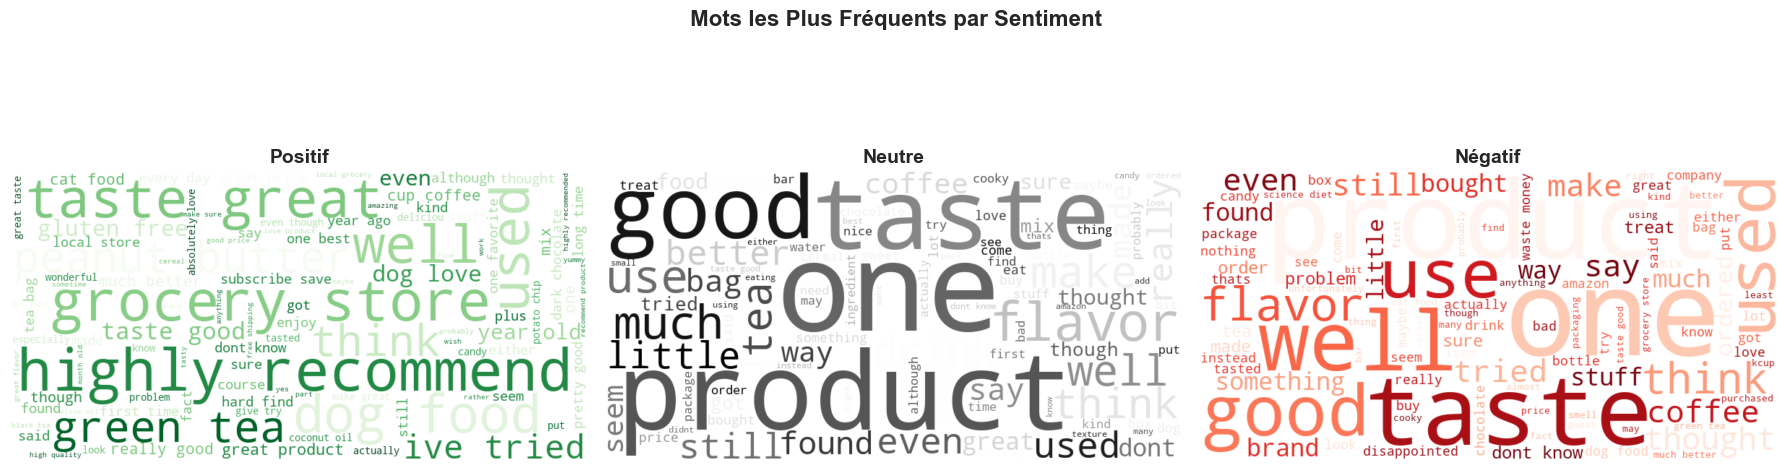


 Tous les word clouds générés avec succès!


In [19]:
# 12. WORD CLOUDS - VISUALISATION DES MOTS FRÉQUENTS


print("GÉNÉRATION DES WORD CLOUDS")


fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(' Mots les Plus Fréquents par Sentiment', fontsize=16, fontweight='bold')

sentiments = ['Positif', 'Neutre', 'Négatif']
colors = ['Greens', 'Greys', 'Reds']

for i, (sentiment, colormap) in enumerate(zip(sentiments, colors)):
    print(f"\n Génération du Word Cloud pour : {sentiment}")
    
    # Combine tous les textes de ce sentiment
    text_data = ' '.join(df[df['Sentiment'] == sentiment]['Cleaned_Text'])
    
    # Génère le word cloud
    wordcloud = WordCloud(
        width=800,
        height=400,
        background_color='white',
        colormap=colormap,
        max_words=100,
        relative_scaling=0.5,
        min_font_size=10
    ).generate(text_data)
    
    # Affiche
    axes[i].imshow(wordcloud, interpolation='bilinear')
    axes[i].set_title(f'{sentiment}', fontsize=14, fontweight='bold')
    axes[i].axis('off')
    
    # Sauvegarde individuellement
    wordcloud.to_file(f'images/wordcloud_{sentiment.lower()}.png')
    print(f" Sauvegardé : images/wordcloud_{sentiment.lower()}.png")

plt.tight_layout()
plt.savefig('images/wordclouds_all.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n Tous les word clouds générés avec succès!")

SYSTÈME DE PRÉDICTION

In [22]:
# 13. SYSTÈME DE PRÉDICTION


class SentimentAnalyzer:
    """
    Système complet d'analyse de sentiments.
    """
    
    def __init__(self, model, vectorizer):
        self.model = model
        self.vectorizer = vectorizer
        self.stop_words = set(stopwords.words('english'))
        self.lemmatizer = WordNetLemmatizer()
    
    def clean_text(self, text):
        """Nettoie et prétraite le texte"""
        text = str(text).lower()
        text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
        text = re.sub(r'@\w+', '', text)
        text = re.sub(r'#', '', text)
        text = text.translate(str.maketrans('', '', string.punctuation))
        text = re.sub(r'\d+', '', text)
        
        tokens = text.split()
        cleaned_tokens = []
        for token in tokens:
            if token not in self.stop_words and len(token) > 2:
                lemmatized = self.lemmatizer.lemmatize(token)
                cleaned_tokens.append(lemmatized)
        
        return ' '.join(cleaned_tokens)
    
    def predict(self, text):
        """Prédit le sentiment d'un texte"""
        # Nettoie le texte
        cleaned = self.clean_text(text)
        
        # Vectorise
        vectorized = self.vectorizer.transform([cleaned])
        
        # Prédit
        prediction = self.model.predict(vectorized)[0]
        
        # Probabilités
        probas = self.model.predict_proba(vectorized)[0]
        
        # Map des classes
        classes = self.model.classes_
        probas_dict = {cls: prob for cls, prob in zip(classes, probas)}
        
        return {
            'sentiment': prediction,
            'confidence': max(probas) * 100,
            'probabilities': probas_dict
        }
    
    def predict_batch(self, texts):
        """Prédit le sentiment pour une liste de textes"""
        results = []
        for text in texts:
            result = self.predict(text)
            results.append(result)
        return results

# Initialise le système
analyzer = SentimentAnalyzer(best_model, tfidf_vectorizer)


print(" SYSTÈME D'ANALYSE DE SENTIMENTS INITIALISÉ")
print(f"\nModèle : {best_model_name}")
print(f"Prêt à analyser des avis !")

 SYSTÈME D'ANALYSE DE SENTIMENTS INITIALISÉ

Modèle : Logistic Regression
Prêt à analyser des avis !


TESTS DU SYSTÈME

In [23]:
# 14. TESTS DU SYSTÈME


print("TESTS DU SYSTÈME DE PRÉDICTION")


# Exemples de test
test_reviews = [
    "This product is absolutely amazing! Best purchase I've ever made.",
    "Terrible quality, complete waste of money. Very disappointed.",
    "It's okay, nothing special but does the job.",
    "I love this! Highly recommend to everyone!",
    "Worst experience ever. Do not buy this product.",
    "Average product, not bad but not great either."
]

print("\n ANALYSE DES EXEMPLES DE TEST\n")

for i, review in enumerate(test_reviews, 1):
    result = analyzer.predict(review)
    
   
    print(f"Exemple {i}")
    print(f"Texte : {review}")
    print(f"\n Prédiction : {result['sentiment']}")
    print(f" Confiance : {result['confidence']:.2f}%")
    print(f"\n Probabilités détaillées :")
    for sentiment, proba in result['probabilities'].items():
        print(f"   {sentiment:10s} : {proba*100:5.2f}%")
    print()

# Test sur des exemples du dataset
print(" VALIDATION SUR DES EXEMPLES DU DATASET")


sample_indices = np.random.choice(len(X_test), 5, replace=False)

for idx in sample_indices:
    original_text = X_test.iloc[idx]
    true_sentiment = y_test.iloc[idx]
    
    result = analyzer.predict(df[df['Cleaned_Text'] == original_text]['Text'].values[0])
    
    is_correct = "correct" if result['sentiment'] == true_sentiment else "incorrect"
    
    print(f"\n{is_correct} Prédiction : {result['sentiment']} | Vraie classe : {true_sentiment}")
    print(f"   Confiance : {result['confidence']:.1f}%")
    print(f"   Texte : {df[df['Cleaned_Text'] == original_text]['Text'].values[0][:100]}...")

TESTS DU SYSTÈME DE PRÉDICTION

 ANALYSE DES EXEMPLES DE TEST

Exemple 1
Texte : This product is absolutely amazing! Best purchase I've ever made.

 Prédiction : Positif
 Confiance : 99.71%

 Probabilités détaillées :
   Neutre     :  0.06%
   Négatif    :  0.23%
   Positif    : 99.71%

Exemple 2
Texte : Terrible quality, complete waste of money. Very disappointed.

 Prédiction : Négatif
 Confiance : 99.99%

 Probabilités détaillées :
   Neutre     :  0.01%
   Négatif    : 99.99%
   Positif    :  0.00%

Exemple 3
Texte : It's okay, nothing special but does the job.

 Prédiction : Neutre
 Confiance : 89.41%

 Probabilités détaillées :
   Neutre     : 89.41%
   Négatif    :  8.92%
   Positif    :  1.68%

Exemple 4
Texte : I love this! Highly recommend to everyone!

 Prédiction : Positif
 Confiance : 100.00%

 Probabilités détaillées :
   Neutre     :  0.00%
   Négatif    :  0.00%
   Positif    : 100.00%

Exemple 5
Texte : Worst experience ever. Do not buy this product.

 Prédiction : Nég

SAUVEGARDE FINALE

In [28]:
# 15. SAUVEGARDE FINALE


print(" SAUVEGARDE FINALE DU PROJET")

# Sauvegarde un fichier de métadonnées
metadata = {
    'best_model': best_model_name,
    'accuracy': best_accuracy,
    'f1_score': best_f1,
    'training_date': datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'dataset_size': len(df),
    'test_size': len(X_test),
    'features': len(tfidf_vectorizer.get_feature_names_out())
}

with open('models/metadata.pkl', 'wb') as f:
    pickle.dump(metadata, f)

print(" Métadonnées sauvegardées : models/metadata.pkl")

# Liste des fichiers créés
print("\n FICHIERS CRÉÉS :")
print("\n Données :")
print("    data/reviews_cleaned.csv")
print("\n Modèles :")
print("    models/tfidf_vectorizer.pkl")
print("    models/best_model.pkl")
print("    models/metadata.pkl")
print("\n Visualisations :")
print("    images/exploratory_analysis.png")
print("    images/confusion_matrix_lr.png")
print("    images/confusion_matrix_rf.png")
print("    images/confusion_matrix_nb.png")
print("    images/model_comparison.png")
print("    images/wordcloud_positif.png")
print("    images/wordcloud_neutre.png")
print("    images/wordcloud_négatif.png")
print("    images/wordclouds_all.png")
print("\n Résultats :")
print("    model_comparison.csv")




 SAUVEGARDE FINALE DU PROJET
 Métadonnées sauvegardées : models/metadata.pkl

 FICHIERS CRÉÉS :

 Données :
    data/reviews_cleaned.csv

 Modèles :
    models/tfidf_vectorizer.pkl
    models/best_model.pkl
    models/metadata.pkl

 Visualisations :
    images/exploratory_analysis.png
    images/confusion_matrix_lr.png
    images/confusion_matrix_rf.png
    images/confusion_matrix_nb.png
    images/model_comparison.png
    images/wordcloud_positif.png
    images/wordcloud_neutre.png
    images/wordcloud_négatif.png
    images/wordclouds_all.png

 Résultats :
    model_comparison.csv
